In [44]:
#Import modules
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import os

#Google Drive Folder Created
drive_directory = '/home/jovyan/data/Tutorial_data/scratch/GEE_test/roblar/S2/'
#List of file names with file path
drive_files = os.listdir(filepath)
print(files)

#Google Drive Folder subfolders
years_directory = '/home/jovyan/data/Tutorial_data/scratch/GEE_test/roblar/S2/2024-07-01'
#List of file names with file path
years_files = os.listdir(years_directory)
print(years_files)

#Google Drive Folder subfolders subfolder
sat_directory = '/home/jovyan/data/Tutorial_data/scratch/GEE_test/roblar/S2/2024-07-01/SAT'
sat_files = os.listdir(sat_directory)
print(sat_files)

#.tif files
tif_file = '/home/jovyan/data/Tutorial_data/scratch/GEE_test/roblar/S2/2024-07-01/SAT/20240801T034541_20240801T035025_T48RTR.tif'

['2024-07-01', '2023-01-01', '2020-07-01', '2016-04-01', '2024-01-01', '2019-07-01', '2017-04-01', '2016-10-01', '2020-04-01', '2023-07-01', '2019-04-01', '2017-01-01', '2022-10-01', '2021-04-01', '2022-04-01', '2023-10-01', '2022-01-01', '2024-04-01', '2021-10-01', '2020-10-01', '2017-10-01', '2018-07-01', '2022-07-01', '2018-10-01', '2018-04-01', '2016-01-01', '2017-07-01', '2016-07-01', '2019-01-01', '2023-04-01', '2019-10-01', '2021-01-01', '2024-10-01', '2020-01-01', '2018-01-01', '2021-07-01']
['SAT']
['20240801T034541_20240801T035025_T48RTR.tif', '20240813T033539_20240813T035000_T48RTQ.tif', '20240821T034531_20240821T035338_T48RTR.tif', '20240813T033539_20240813T035000_T48RTR.tif', '20240801T034541_20240801T035025_T48RTQ.tif']


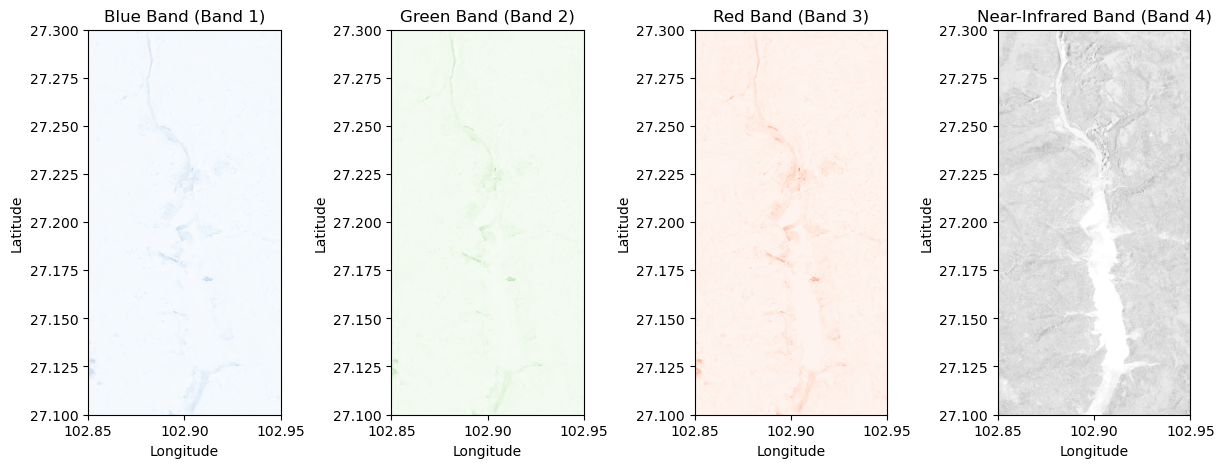

Number of Bands: 4
Width (columns): 1115
Height (rows): 2228
CRS: EPSG:4326
Transform: | 0.00, 0.00, 102.85|
| 0.00,-0.00, 27.30|
| 0.00, 0.00, 1.00|


In [45]:
#.tif files
tif_file = '/home/jovyan/data/Tutorial_data/scratch/GEE_test/roblar/S2/2024-07-01/SAT/20240801T034541_20240801T035025_T48RTR.tif'

#Visulaise the bands
#Open the file with rasterio
with rasterio.open(tif_file) as dataset:
    # Read the bands (Blue, Green, Red, Near-Infrared)
    blue_band = dataset.read(1)  # Blue band (Band 1)
    green_band = dataset.read(2) # Green band (Band 2)
    red_band = dataset.read(3)   # Red band (Band 3)
    nir_band = dataset.read(4)   # Near-Infrared band (Band 4)

    #Get the transform and CRS
    transform = dataset.transform
    crs = dataset.crs

    #Get the coordinates of the top-left and bottom-right corners of the image
    top_left = transform * (0, 0)  # Coordinates of the top-left corner (row 0, col 0)
    bottom_right = transform * (dataset.width, dataset.height)  # Bottom-right corner (width, height)
    
    #Extract the coordinates
    left, top = top_left
    right, bottom = bottom_right
    
    #Define the extent for the plot
    extent = (left, right, bottom, top)

    #Plot the bands
    fig, axes = plt.subplots(1, 4, figsize=(15, 5))

    #Blue Band
    axes[0].imshow(blue_band, cmap='Blues', extent=extent)
    axes[0].set_title("Blue Band (Band 1)")
    axes[0].set_xlabel('Longitude')
    axes[0].set_ylabel('Latitude')

    #Green Band
    axes[1].imshow(green_band, cmap='Greens', extent=extent)
    axes[1].set_title("Green Band (Band 2)")
    axes[1].set_xlabel('Longitude')
    axes[1].set_ylabel('Latitude')

    #Red Band
    axes[2].imshow(red_band, cmap='Reds', extent=extent)
    axes[2].set_title("Red Band (Band 3)")
    axes[2].set_xlabel('Longitude')
    axes[2].set_ylabel('Latitude')

    #Near-Infrared Band
    axes[3].imshow(nir_band, cmap='Greys', extent=extent)
    axes[3].set_title("Near-Infrared Band (Band 4)")
    axes[3].set_xlabel('Longitude')
    axes[3].set_ylabel('Latitude')

    plt.show()

#Metadata of .tif
print("Number of Bands:", dataset.count)
print("Width (columns):", dataset.width)
print("Height (rows):", dataset.height)
print("CRS:", crs)
print("Transform:", dataset.transform)

In [46]:
#Open the file with rasterio
with rasterio.open(tif_file) as dataset:
    # Read the bands (Blue, Green, Red, Near-Infrared)
    blue_band = dataset.read(1)  # Blue band (Band 1)
    green_band = dataset.read(2) # Green band (Band 2)
    red_band = dataset.read(3)   # Red band (Band 3)
    nir_band = dataset.read(4)   # Near-Infrared band (Band 4)

    #Map pixel coordinates to spatial coordinates
    transform = dataset.transform

#Row and column indices
rows, cols = np.indices(blue_band.shape)

#Convert row and column indices to spatial coordinates
x, y = rasterio.transform.xy(transform, rows, cols)

#Flatten the arrays so they are 1D
x = np.array(x).flatten()
y = np.array(y).flatten()
blue = blue_band.flatten()
green = green_band.flatten()
red = red_band.flatten()
nir = nir_band.flatten()

#Create dataframe containing pixel values and coordinates
damdata = pd.DataFrame({
    'Longitude': x,
    'Latitude': y,
    'Blue': blue,
    'Green': green,
    'Red': red,
    'NIR': nir
})

#Display dataframe
damdata.head()

,Longitude,Latitude,Blue,Green,Red,NIR
0,102.849958,27.300026,189,404,235,2699
1,102.850048,27.300026,166,387,204,2479
2,102.850138,27.300026,187,425,230,2525
3,102.850228,27.300026,187,425,230,2525
4,102.850318,27.300026,246,488,341,2520


In [50]:
#Information about the dataset
damdata.describe()

,Longitude,Latitude,Blue,Green,Red,NIR,NDVI,NSMI,NDSSI
count,2.484220e+06,2.484220e+06,2.484220e+06,2.484220e+06,2.484220e+06,2.484220e+06,2.484220e+06,2.484057e+06,2.484193e+06
mean,1.029000e+02,2.720000e+01,3.296630e+02,6.460838e+02,4.591529e+02,3.328768e+03,1.794586e+01,5.852867e-01,1.612026e+01
std,2.891432e-02,5.777679e-02,3.956082e+02,4.057633e+02,4.512686e+02,1.157426e+03,7.781301e+01,5.995166e+00,4.953621e+01
min,1.028500e+02,2.709997e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.089562e-03,0.000000e+00
25%,1.028749e+02,2.714998e+01,1.720000e+02,4.480000e+02,2.350000e+02,2.916000e+03,7.671443e-01,5.549924e-01,1.373837e+01
50%,1.029000e+02,2.720000e+01,2.200000e+02,5.520000e+02,3.160000e+02,3.514000e+03,8.478321e-01,5.907970e-01,1.583006e+01
75%,1.029251e+02,2.725001e+01,3.110000e+02,6.980000e+02,4.830000e+02,4.020000e+03,8.908179e-01,6.201991e-01,1.832163e+01
max,1.029500e+02,2.730003e+01,1.933600e+04,1.796000e+04,1.720800e+04,1.604100e+04,7.280778e+03,9.361286e+03,6.553500e+04


In [48]:
#Shows the highest pixel value in each band
print('Red: '+ str(damdata['Blue'].max()))
print('Blue: '+ str(damdata['Green'].max()))
print('Green: '+ str(damdata['Red'].max()))
print('NIR: '+ str(damdata['NIR'].max()))

Red: 19336
Blue: 17960
Green: 17208
NIR: 16041


In [49]:
#Add Additional Indexes to use

#Normalized Difference Vegetation Index (NDVI) from: https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/ndvi/
#NDVI = (NIR - Red)/(NIR + Red)
damdata['NDVI'] = (damdata['NIR'] - damdata['Red']) / (damdata['NIR'] + damdata['Red'])
#Normalized Suspended Material Index (NSMI) from: https://iopscience.iop.org/article/10.1088/1755-1315/98/1/012058/pdf#:~:text=The%20equation%20to%20identify%20the,by%20the%20presence%20of%20SM.
#NSMI = (Red + Green - Blue)/(Red + Green + Blue)
damdata['NSMI'] = (damdata['Red'] + damdata['Green'] - damdata['Blue']) / (damdata['Red'] + damdata['Green'] + damdata['Blue'])
#Normalized Differences Suspended Sediment Index(NDSSI) from: https://iopscience.iop.org/article/10.1088/1755-1315/98/1/012058/pdf#:~:text=The%20equation%20to%20identify%20the,by%20the%20presence%20of%20SM.
#NDSSI = (Blue - NIR)/(Blue + NIR)
damdata['NDSSI'] = (damdata['Blue'] - damdata['NIR']) / (damdata['Blue'] + damdata['NIR'])

#Display dataframe
damdata.head()

,Longitude,Latitude,Blue,Green,Red,NIR,NDVI,NSMI,NDSSI
0,102.849958,27.300026,189,404,235,2699,0.839809,0.543478,21.823407
1,102.850048,27.300026,166,387,204,2479,0.847931,0.561427,23.902836
2,102.850138,27.300026,187,425,230,2525,0.833031,0.555819,23.303097
3,102.850228,27.300026,187,425,230,2525,0.833031,0.555819,23.303097
4,102.850318,27.300026,246,488,341,2520,0.761622,0.542326,22.871294
